---
### **Task 1.0 — Project Workspace Configrations**



In [1]:
import os

def print_project_structure(path, prefix="", max_depth=3, current_depth=0):
    """
    Recursively prints the directory tree to verify the
    Hadoop-ready project workspace.
    """
    if current_depth >= max_depth:
        return
    try:
        entries = sorted(os.listdir(path))
    except PermissionError:
        return

    for i, entry in enumerate(entries):
        # Visual connectors for the tree view
        connector = "└── " if i == len(entries)-1 else "├── "
        full_path = os.path.join(path, entry)
        print(prefix + connector + entry)

        if os.path.isdir(full_path):
            extension = "    " if i == len(entries)-1 else "│   "
            print_project_structure(full_path, prefix + extension, max_depth, current_depth+1)

# Set and verify project root on CentOS
project_root = os.path.expanduser("~/arabic_ai_detection")
print(f"Project Workspace: {project_root}")
print("-" * 40)
print_project_structure(project_root)
print("-" * 40)

Project Workspace: /home/ahmed/arabic_ai_detection
----------------------------------------
├── data
│   ├── processed
│   │   └── abstracts_preprocessed.parquet
│   └── raw
│       └── abstracts_raw.parquet
├── models
├── notebooks
├── reports
│   └── figures
│       ├── preprocessed_len_dist.png
│       ├── ttr_eda_distribution.png
│       └── wordcloud.png
├── scripts
└── venv
    ├── bin
    │   ├── Activate.ps1
    │   ├── __pycache__
    │   ├── activate
    │   ├── activate.csh
    │   ├── activate.fish
    │   ├── beeline
    │   ├── beeline.cmd
    │   ├── datasets-cli
    │   ├── debugpy
    │   ├── debugpy-adapter
    │   ├── docker-image-tool.sh
    │   ├── f2py
    │   ├── find-spark-home
    │   ├── find-spark-home.cmd
    │   ├── find_spark_home.py
    │   ├── fonttools
    │   ├── get_gprof
    │   ├── get_objgraph
    │   ├── hf
    │   ├── httpx
    │   ├── huggingface-cli
    │   ├── ipython
    │   ├── ipython3
    │   ├── jlpm
    │   ├── jsonpointer
    │   ├── js

In [2]:

import seaborn as sns
import pandas as pd
import numpy as np

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt

---
## **Phase 1: Environment Setup and Data Acquisition**

**Tasks:** 1.1 – 1.4



---
### Task 1.1 — Install Required Libraries

Install Python packages needed for the project. Run once inside your project virtual environment.

In [4]:
import subprocess, sys

packages = [
    "datasets",
    "huggingface_hub",
    "pyarabic",
    "regex",
    "nltk",
    "wordcloud",
    "seaborn",
    "pyarrow",
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", pkg,
                           "--trusted-host", "pypi.org",
                           "--trusted-host", "files.pythonhosted.org"])

print("All packages installed successfully.")

All packages installed successfully.


  ---

### **Task 1.2 — Initialize SparkSession in Local Mode**
.

In [5]:
import os
from pyspark.sql import SparkSession
from pyspark import SparkConf

# --- Define Project Paths ---
PROJECT_ROOT   = os.path.expanduser("~/arabic_ai_detection")
DATA_RAW       = os.path.join(PROJECT_ROOT, "data", "raw")
DATA_PROCESSED = os.path.join(PROJECT_ROOT, "data", "processed")
MODELS_DIR     = os.path.join(PROJECT_ROOT, "models")
REPORTS_DIR    = os.path.join(PROJECT_ROOT, "reports", "figures")

# Ensure all local directories exist
for d in [DATA_RAW, DATA_PROCESSED, MODELS_DIR, REPORTS_DIR]:
    os.makedirs(d, exist_ok=True)

LOCAL_RAW_PATH  = os.path.join(DATA_RAW,       "abstracts_raw.parquet")

# --- Initialize SparkSession ---
conf = (
    SparkConf()
    .setAppName("ArabicAITextDetection")
    .setMaster("local[*]")
    .set("spark.driver.memory", "4g")
    .set("spark.executor.memory", "4g")
    .set("spark.sql.shuffle.partitions", "8")
    .set("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .set("spark.driver.extraJavaOptions", "-Dfile.encoding=UTF-8")
)

spark = SparkSession.builder.config(conf=conf).getOrCreate()
sc = spark.sparkContext
sc.setLogLevel("ERROR")

print("Spark version      :", spark.version)
print("Application name   :", sc.appName)
print("Master URL         :", sc.master)
print("Default parallelism:", sc.defaultParallelism)
print("Project root       :", PROJECT_ROOT)
print("Spark UI           : http://localhost:4040")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/04 02:20:29 WARN Utils: Your hostname, localhost.localdomain, resolves to a loopback address: 127.0.0.1; using 10.0.2.15 instead (on interface enp0s3)
26/05/04 02:20:29 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/04 02:20:30 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version      : 4.1.1
Application name   : ArabicAITextDetection
Master URL         : local[*]
Default parallelism: 4
Project root       : /home/ahmed/arabic_ai_detection
Spark UI           : http://localhost:4040


---
### Task 1.3 — Download Dataset & Save to Local Parquet

Download the dataset from Hugging Face

In [6]:
# Downloading from Hugging Face

import os
from datasets import load_dataset

# Set HF_TOKEN if the environment requires authentication
HF_TOKEN = os.environ.get("HF_TOKEN", None)
if HF_TOKEN:
    from huggingface_hub import login
    login(token=HF_TOKEN, add_to_git_credential=False)

# Load the Arabic generated abstracts dataset
dataset = load_dataset("KFUPM-JRCAI/arabic-generated-abstracts")

print("Dataset splits:", list(dataset.keys()))
for split_name, split_data in dataset.items():
    print(f"  {split_name}: {len(split_data):,} rows | columns: {split_data.column_names}")

/home/ahmed/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset splits: ['by_polishing', 'from_title', 'from_title_and_content']
  by_polishing: 2,851 rows | columns: ['original_abstract', 'allam_generated_abstract', 'jais_generated_abstract', 'llama_generated_abstract', 'openai_generated_abstract']
  from_title: 2,963 rows | columns: ['original_abstract', 'allam_generated_abstract', 'jais_generated_abstract', 'llama_generated_abstract', 'openai_generated_abstract']
  from_title_and_content: 2,574 rows | columns: ['original_abstract', 'allam_generated_abstract', 'jais_generated_abstract', 'llama_generated_abstract', 'openai_generated_abstract']


In [7]:
# Data Consolidation (Data Flattening)

import pandas as pd

rows = []
for split_name in ["by_polishing", "from_title", "from_title_and_content"]:
    split_df = dataset[split_name].to_pandas()

    for _, row in split_df.iterrows():
        # Label 1: Human-written (Original) abstract
        rows.append({
            "abstract_text": row["original_abstract"],
            "source_split":  split_name,
            "generated_by":  "human",
            "label":         1
        })

        # Label 0: AI-generated abstracts from multiple models
        for model_name in ["allam", "jais", "llama", "openai"]:
            col = f"{model_name}_generated_abstract"
            if col in row and pd.notna(row[col]):
                rows.append({
                    "abstract_text": row[col],
                    "source_split":  split_name,
                    "generated_by":  model_name,
                    "label":         0
                })

# Create a unified Pandas DataFrame
pdf = pd.DataFrame(rows)

print("Unified Pandas DataFrame shape:", pdf.shape)
print(pdf["label"].value_counts().rename({1: "Human (1)", 0: "AI (0)"}))

Unified Pandas DataFrame shape: (41940, 4)
label
AI (0)       33552
Human (1)     8388
Name: count, dtype: int64


In [8]:
# --- Save to local Parquet for high-performance processing ---

pdf.to_parquet(LOCAL_RAW_PATH, index=False, engine="pyarrow")

print("Raw Parquet saved locally:", LOCAL_RAW_PATH)
print("File size:", round(os.path.getsize(LOCAL_RAW_PATH) / 1024 / 1024, 2), "MB")

Raw Parquet saved locally: /home/ahmed/arabic_ai_detection/data/raw/abstracts_raw.parquet
File size: 18.53 MB


---
### Task 1.4 — Initial Data Exploration with Spark DataFrames

Load the dataset from local Parquet into a Spark DataFrame and perform comprehensive Exploratory Data Analysis (EDA).

In [9]:
# Download data and view Schema

from pyspark.sql import functions as F
from pyspark.sql.types import StringType, IntegerType

# --- Load data from local Parquet and cache for performance ---
raw_df = spark.read.parquet(LOCAL_RAW_PATH)
raw_df.cache()

print("=== Dataset Schema ===")
raw_df.printSchema()

print("\n=== Total Record Count ===")
print(f"Total Rows: {raw_df.count():,}")

print("\n=== Sample Records (First 5) ===")
raw_df.show(5, truncate=80)

=== Dataset Schema ===
root
 |-- abstract_text: string (nullable = true)
 |-- source_split: string (nullable = true)
 |-- generated_by: string (nullable = true)
 |-- label: long (nullable = true)


=== Total Record Count ===


Total Rows: 41,940

=== Sample Records (First 5) ===
+--------------------------------------------------------------------------------+------------+------------+-----+
|                                                                   abstract_text|source_split|generated_by|label|
+--------------------------------------------------------------------------------+------------+------------+-----+
|كثيرا ما ارتبطت المصادر التاريخية في الأندلس خاصة منها كتب التراجم والفهرسات ...|by_polishing|       human|    1|
|يتناول هذا البحث موضوع التعليم بين النساء الأندلسيات من خلال دراسة المصادر ال...|by_polishing|       allam|    0|
|تدرس هذه الدراسة دور المرأة في التعليم في الأندلس من خلال مصادر تاريخية مثل ك...|by_polishing|        jais|    0|
|يُقدم هذا البحث دراسة شاملة حول حالة التعليم عند المرأة الأندلسية خلال العصور...|by_polishing|       llama|    0|
|صور نظام التعليم عند المرأة الأندلسية تستند إلى دراسة دقيقة للمصادر التاريخية...|by_polishing|      openai|    0|
+--------------------------

In [10]:
# Calculate distribution percentages

total_count = raw_df.count()
label_dist = (raw_df.groupBy("label", "generated_by")
              .count()
              .orderBy("label", "generated_by")
              .withColumn("percentage", F.round(F.col("count") / total_count * 100, 2)))

print("=== Class Distribution Statistics ===")
label_dist.show(truncate=False)

print("=== Data Source Split Distribution ===")
raw_df.groupBy("source_split").count().show()

=== Class Distribution Statistics ===
+-----+------------+-----+----------+
|label|generated_by|count|percentage|
+-----+------------+-----+----------+
|0    |allam       |8388 |20.0      |
|0    |jais        |8388 |20.0      |
|0    |llama       |8388 |20.0      |
|0    |openai      |8388 |20.0      |
|1    |human       |8388 |20.0      |
+-----+------------+-----+----------+

=== Data Source Split Distribution ===
+--------------------+-----+
|        source_split|count|
+--------------------+-----+
|        by_polishing|14255|
|from_title_and_co...|12870|
|          from_title|14815|
+--------------------+-----+



In [11]:
# Checking missing and duplicate values

print("=== Missing Values Analysis (Null Check) ===")
raw_df.select([F.sum(F.col(c).isNull().cast("int")).alias(c)
               for c in raw_df.columns]).show()

print("=== Duplicate Content Analysis ===")
unique_count = raw_df.dropDuplicates(["abstract_text"]).count()
dup_count = total_count - unique_count

print(f"  Total Duplicates found in 'abstract_text': {dup_count:,}")

=== Missing Values Analysis (Null Check) ===
+-------------+------------+------------+-----+
|abstract_text|source_split|generated_by|label|
+-------------+------------+------------+-----+
|            0|           0|           0|    0|
+-------------+------------+------------+-----+

=== Duplicate Content Analysis ===


[Stage 19:===========================================>              (3 + 1) / 4]

  Total Duplicates found in 'abstract_text': 5,415


In [12]:
# Compute text length metrics (Characters and Words)

stats_df = (
    raw_df
    .withColumn("char_count", F.length("abstract_text"))
    .withColumn("word_count", F.size(F.split("abstract_text", r"\s+")))
    .groupBy("label")
    .agg(
        F.round(F.mean("char_count"), 2).alias("avg_chars"),
        F.round(F.stddev("char_count"), 2).alias("std_chars"),
        F.min("char_count").alias("min_chars"),
        F.max("char_count").alias("max_chars"),
        F.round(F.mean("word_count"), 2).alias("avg_words")
    )
)

print("=== Text Length Statistics per Label (Human vs AI) ===")
stats_df.show()

=== Text Length Statistics per Label (Human vs AI) ===


[Stage 25:===========================================>              (3 + 1) / 4]

+-----+---------+---------+---------+---------+---------+
|label|avg_chars|std_chars|min_chars|max_chars|avg_words|
+-----+---------+---------+---------+---------+---------+
|    1|   740.31|   226.59|      411|     1891|   119.16|
|    0|    654.6|   261.48|      170|    18459|   101.49|
+-----+---------+---------+---------+---------+---------+



### Calculating Linguistic Diversity Feature ( TTR)
 we use the Spark RDD API to calculate the Type-Token Ratio (TTR) as part of our initial feature exploration.

In [13]:
import matplotlib.pyplot as plt

# Feature #2: Type-Token Ratio (Unique Words / Total Words)
ttr_rdd = (
    raw_df.select("abstract_text", "label").rdd
    .map(lambda r: (
        int(r["label"]),
        len(set(r["abstract_text"].split())) / len(r["abstract_text"].split())
        if r["abstract_text"] and len(r["abstract_text"].split()) > 0 else 0.0
    ))
)


# Convert to Pandas for visualization
ttr_pdf = ttr_rdd.toDF(["label", "ttr"]).toPandas()

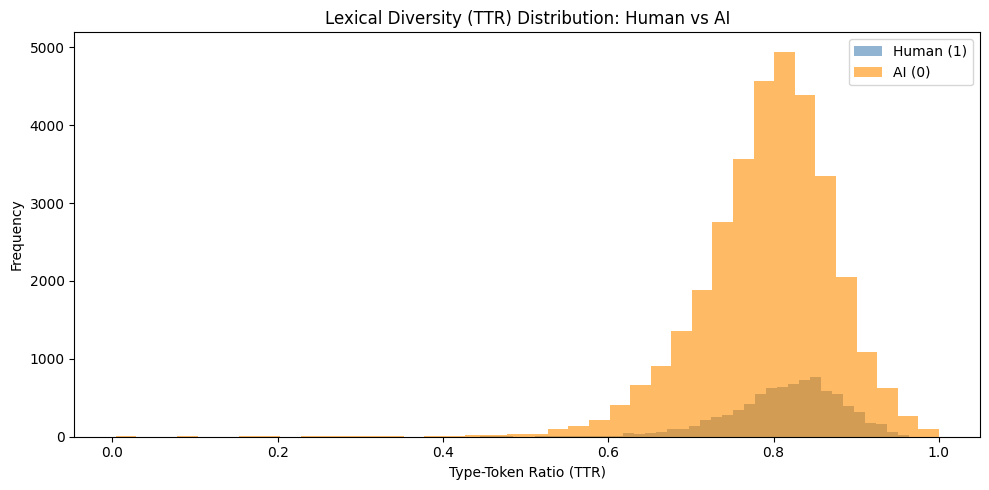

Plot saved to: /home/ahmed/arabic_ai_detection/reports/figures/ttr_eda_distribution.png
Average Human TTR: 0.8142 | Average AI TTR: 0.7927


In [14]:
# Drawing and storing TTR results

import seaborn as sns

# Extract series for statistics
human_ttr = ttr_pdf[ttr_pdf["label"] == 1]["ttr"]
ai_ttr    = ttr_pdf[ttr_pdf["label"] == 0]["ttr"]

# Plotting the TTR Distribution
plt.figure(figsize=(10, 5))
plt.hist(human_ttr, bins=40, alpha=0.6, label="Human (1)", color="steelblue")
plt.hist(ai_ttr,    bins=40, alpha=0.6, label="AI (0)",    color="darkorange")

plt.xlabel("Type-Token Ratio (TTR)")
plt.ylabel("Frequency")
plt.title("Lexical Diversity (TTR) Distribution: Human vs AI")
plt.legend()
plt.tight_layout()

# Save the plot to the reports directory
ttr_plot_path = os.path.join(REPORTS_DIR, "ttr_eda_distribution.png")
plt.savefig(ttr_plot_path, dpi=150)
plt.show()

print(f"Plot saved to: {ttr_plot_path}")
print(f"Average Human TTR: {human_ttr.mean():.4f} | Average AI TTR: {ai_ttr.mean():.4f}")

---
## Phase 2: Distributed Data Preprocessing & Storage

>**Tasks:** 2.1 – 2.3


---
###  Task 2.1 — Arabic Text Preprocessing Pipeline (Spark UDFs)


In [15]:
# Defining Processing Functions (Preprocessing Functions)

import re
import nltk
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType

# Ensure NLTK resources are available
nltk.download("stopwords", quiet=True)

def _remove_diacritics(text: str) -> str:
    if not isinstance(text, str): return ""
    arabic_diacritics = re.compile(r"[\u0617-\u061A\u064B-\u065F]")
    return arabic_diacritics.sub("", text)

def _normalize_arabic(text: str) -> str:
    if not isinstance(text, str): return ""
    # Standardizing characters
    text = re.sub(r"[إأآا]", "ا", text)
    text = re.sub(r"ى", "ي", text)
    text = re.sub(r"ة", "ه", text)
    # Keeping only Arabic letters and spaces
    text = re.sub(r"[^\u0600-\u06FF\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def _remove_stopwords(text: str) -> str:
    from nltk.corpus import stopwords
    if not isinstance(text, str): return ""
    ar_stopwords = set(stopwords.words("arabic"))
    return " ".join(w for w in text.split() if w not in ar_stopwords)

def _stem_arabic(text: str) -> str:
    try:
        from nltk.stem.isri import ISRIStemmer
        stemmer = ISRIStemmer()
        if not isinstance(text, str): return ""
        return " ".join(stemmer.stem(w) for w in text.split())
    except Exception:
        return text

def full_arabic_preprocess(text: str) -> str:
    """Combines all preprocessing steps into one pipeline."""
    text = _remove_diacritics(text)
    text = _normalize_arabic(text)
    text = _remove_stopwords(text)
    text = _stem_arabic(text)
    return text

# Register the function as a Spark UDF for distributed execution
preprocess_udf = udf(full_arabic_preprocess, StringType())
print("Distributed Preprocessing UDFs registered successfully.")

Distributed Preprocessing UDFs registered successfully.


/home/ahmed/.local/lib/python3.12/site-packages/pyspark/sql/udf.py:134: UserWarning: Cannot infer the eval type from type hints. 
  warnings.warn("Cannot infer the eval type from type hints. ", UserWarning)


In [16]:
# Processing execution (Execution)

from pyspark.sql import functions as F

# Clean raw data: remove Nulls, duplicates, and apply the UDF
preprocessed_df = (
    raw_df
    .filter(F.col("abstract_text").isNotNull() & (F.trim(F.col("abstract_text")) != ""))
    .dropDuplicates(["abstract_text"])
    .withColumn("abstract_text_clean", preprocess_udf(F.col("abstract_text")))
)

print(f"Total Preprocessed Rows: {preprocessed_df.count():,}")
preprocessed_df.select("abstract_text", "abstract_text_clean").show(3, truncate=80)

Total Preprocessed Rows: 36,525


[Stage 39:>                                                         (0 + 1) / 1]

+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                                                                   abstract_text|                                                             abstract_text_clean|
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|يُقدم هذا البحث دراسة شاملة حول حالة التعليم عند المرأة الأندلسية خلال العصور...|قدم بحث درس شمل حول حله علم راه دلس خلل عصر وسط كشف بحث خلل لسل ؤلف ارخ اندلس...|
|صور نظام التعليم عند المرأة الأندلسية تستند إلى دراسة دقيقة للمصادر التاريخية...|صور نظم علم راه دلس سند الي درس دقق صدر ارخ وثق حيه علماء ثقف دلس، سيم كتب رج...|
|انهيار دولة الموحدين يعود بشكل كبير للعوامل الثقافية، التي لا تقل أهمية عن ال...|هير دول وحد يعد شكل كبر عمل ثقافيه، تقل اهم عمل سيس عسكر بدئ فكر عقد ابن رت، ...|
+---------------

---
###  Task 2.2 — Store Processed Data in Local Parquet


In [17]:
# Save processed data (Storage)

# --- Define the Processed Data Path ---
LOCAL_PROC_PATH = os.path.join(DATA_PROCESSED, "abstracts_preprocessed.parquet")

# Partition by label and save to local storage
(
    preprocessed_df
    .repartition(8, "label")
    .write
    .mode("overwrite")
    .partitionBy("label")
    .parquet(LOCAL_PROC_PATH)
)

print(f"Processed data successfully saved to: {LOCAL_PROC_PATH}")
print("Disk Partitions:", os.listdir(LOCAL_PROC_PATH))

[Stage 45:==================================================>       (7 + 1) / 8]

Processed data successfully saved to: /home/ahmed/arabic_ai_detection/data/processed/abstracts_preprocessed.parquet
Disk Partitions: ['label=0', 'label=1', '_SUCCESS', '._SUCCESS.crc']


In [18]:
# Storage Validation (Verification)

# Verify saved data by reading it back from disk
proc_verify = spark.read.parquet(LOCAL_PROC_PATH)
print(f"Row count verified from disk: {proc_verify.count():,}")

# Calculate total storage size
total_size_mb = 0
for dirpath, _, filenames in os.walk(LOCAL_PROC_PATH):
    for f in filenames:
        total_size_mb += os.path.getsize(os.path.join(dirpath, f))

print(f"Total Parquet size on disk: {total_size_mb/1024/1024:.2f} MB")
proc_verify.select("label", "abstract_text_clean").show(3, truncate=80)

Row count verified from disk: 36,525
Total Parquet size on disk: 28.64 MB
+-----+--------------------------------------------------------------------------------+
|label|                                                             abstract_text_clean|
+-----+--------------------------------------------------------------------------------+
|    0|رجز بلد حضن عبر خطط ندر سلط ضوء علي قيم ربو اجتماعيه ثقف عرب سلم خلل فتر زمن ...|
|    0|وزن يقع شكل صطلح شعر عرب هدف بحث الي درس حلل مفاهيم تعلق وزن يقع شعر عربي، تق...|
|    0|عرض ورق بحث تقن حجج فهم بلغ جدد قدم لسف شاييم بيرلمان، ناول كيف تطر بلغ فن خط...|
+-----+--------------------------------------------------------------------------------+
only showing top 3 rows


- ----
### Task 2.3 — EDA on Distributed Data and MapReduce  Statistics


In [19]:
# Loading Data for Analysis (Loading for EDA)


# Cache the processed dataframe for intensive EDA
proc_df = spark.read.parquet(LOCAL_PROC_PATH)
proc_df.cache()

print("Cleaned Data ready for analysis.")

Cleaned Data ready for analysis.


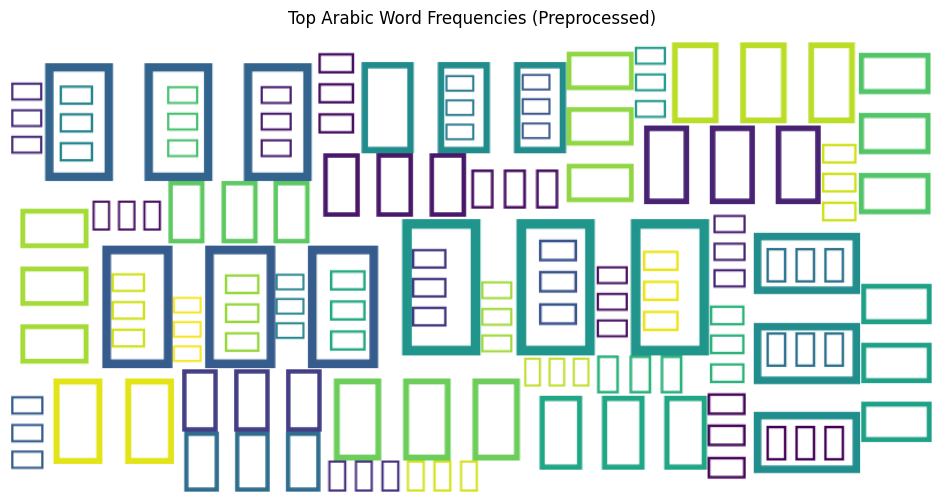

Word cloud visualization saved to: /home/ahmed/arabic_ai_detection/reports/figures/wordcloud.png


In [20]:
# Word Cloud

from wordcloud import WordCloud
from pyspark.sql.functions import explode, split, col


# Extract top words using Spark transformations
top_words = (
    proc_df.select(F.explode(F.split("abstract_text_clean", r"\s+")).alias("word"))
    .groupBy("word").count()
    .orderBy(F.col("count").desc())
    .limit(50)
    .toPandas()
)

try:
    wc = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(
        dict(zip(top_words["word"], top_words["count"]))
    )
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("Top Arabic Word Frequencies (Preprocessed)")

    wc_path = os.path.join(REPORTS_DIR, "wordcloud.png")
    plt.savefig(wc_path, dpi=150); plt.show()
    print(f"Word cloud visualization saved to: {wc_path}")
except Exception as e:
    print(f"Word cloud generation skipped due to: {e}")

---
### Manual MapReduce Application (RDD MapReduce)


> This implementation explicitly follows the Map-Reduce paradigm  using Spark RDDs.

In [21]:
# Step 1: Map - Transform text into (word, 1) tuples

texts_rdd = proc_df.select("abstract_text_clean").rdd.map(lambda r: r[0] or "")

word_counts_rdd = (
    texts_rdd
    .flatMap(lambda text: text.split())   # Split text into words
    .map(lambda word: (word, 1))         # Map each word to 1
    .reduceByKey(lambda a, b: a + b)     # Reduce by summing counts
    .sortBy(lambda kv: kv[1], ascending=False)
)

print("=== MapReduce Result: Top 20 Words ===")
for word, cnt in word_counts_rdd.take(20):
    print(f"  {word}: {cnt}")

=== MapReduce Result: Top 20 Words ===


[Stage 62:===========================================>              (3 + 1) / 4]

  علي: 89367
  الي: 70929
  درس: 66307
  بحث: 53427
  علم: 37540
  ان: 32978
  حلل: 31232
  هدف: 30251
  جمع: 29295
  عمل: 26274
  خلل: 24473
  اثر: 23123
  خدم: 21862
  جزر: 20865
  فهم: 20757
  حقق: 20515
  عزز: 20009
  شكل: 19478
  نتج: 19365
  فعل: 18211


In [22]:
# Hapax Legomena Analysis: words that appeared only once)

# Using the previous MapReduce result to count unique occurrences
hapax_count = word_counts_rdd.filter(lambda kv: kv[1] == 1).count()
total_vocab = word_counts_rdd.count()

print(f"Total Unique Vocabulary Size: {total_vocab:,}")
print(f"Hapax Legomena Count: {hapax_count:,} ({hapax_count/total_vocab*100:.1f}%)")

Total Unique Vocabulary Size: 26,628
Hapax Legomena Count: 10,400 (39.1%)


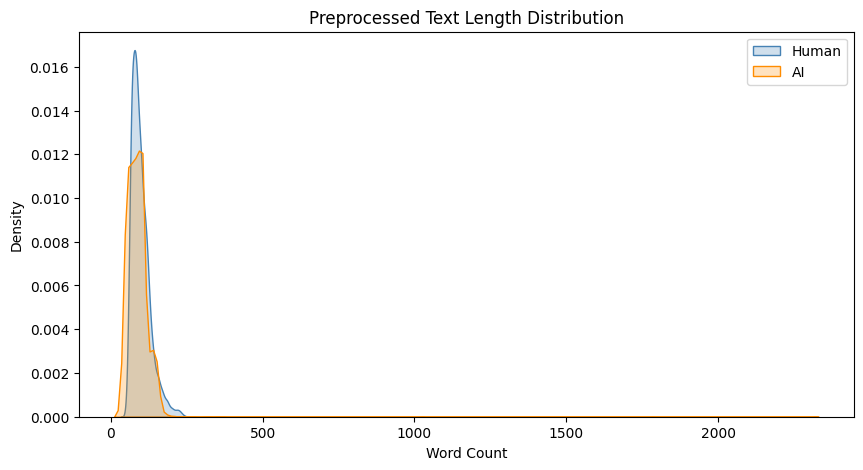

In [23]:
# Word Length Distribution (Text Length Distribution)

import seaborn as sns

# Analyze word count per document between Human and AI labels
len_pdf = (
    proc_df
    .withColumn("word_count", F.size(F.split("abstract_text_clean", r"\s+")))
    .groupBy("label", "word_count").count()
    .toPandas()
)

# Reconstructing distributions for visualization
human_dist = len_pdf[len_pdf["label"]==1].apply(lambda x: [x['word_count']] * int(x['count']), axis=1).sum()
ai_dist    = len_pdf[len_pdf["label"]==0].apply(lambda x: [x['word_count']] * int(x['count']), axis=1).sum()

plt.figure(figsize=(10, 5))
sns.kdeplot(human_dist, label="Human", fill=True, color="steelblue")
sns.kdeplot(ai_dist, label="AI", fill=True, color="darkorange")
plt.title("Preprocessed Text Length Distribution")
plt.xlabel("Word Count")
plt.legend(); plt.show()

In [24]:
# Save Phase 2 Reports

# Save final distribution plot
dist_path = os.path.join(REPORTS_DIR, "preprocessed_len_dist.png")
plt.savefig(dist_path)
print(f"Phase 2 Analytics saved to: {dist_path}")

Phase 2 Analytics saved to: /home/ahmed/arabic_ai_detection/reports/figures/preprocessed_len_dist.png


<Figure size 640x480 with 0 Axes>

In [25]:
# Memory Cleaning (Memory Management)

# Unpersist to free up RAM on the VM
proc_df.unpersist()
print("Memory cleared for the next Phase.")

Memory cleared for the next Phase.


---
## **Phase 3: Scalable Feature Engineering and Batch Modeling**
> **Tasks:** 3.1 – 3.5

In this phase, we extract discriminative stylometric features

---
### Task 3.1 — Stylometric Feature Engineering (Spark UDFs)


In [26]:
import regex
from pyspark.sql.functions import udf, col
from pyspark.sql.types import DoubleType, IntegerType

# --- Helper: Punctuation Extractor ---
def _get_unique_punctuation_count(text: str):
    if not isinstance(text, str) or not text.strip():
        return 0
    # العثور على كل ما هو ليس حرفاً أو رقماً أو مسافة
    punctuations = regex.findall(r'[^\w\s]', text)
    return len(set(punctuations))

# --- Active Feature #1: Total Characters (C) ---
@udf(IntegerType())
def f1_total_chars(text):
    if not isinstance(text, str) or not text:
        return 0
    return len(text)

# --- Active Feature #24: Unique Punctuation Ratio ---
@udf(DoubleType())
def f24_unique_punct_ratio(text):
    if not isinstance(text, str) or len(text) == 0:
        return 0.0

    unique_count = _get_unique_punctuation_count(text)

    return float(unique_count) / len(text)

print("Stylometric UDFs (F1 & F24) with Helper functions registered successfully.")



Stylometric UDFs (F1 & F24) with Helper functions registered successfully.


In [27]:
# --- Application ---
feat_df = (
    proc_df
    .withColumn("f1_total_chars", f1_total_chars("abstract_text"))
    .withColumn("f24_unique_punct_ratio", f24_unique_punct_ratio("abstract_text"))
)

feat_df.cache()
feat_df.select("label", "f1_total_chars", "f24_unique_punct_ratio").show(3)

[Stage 74:======================================>                   (2 + 1) / 3]

+-----+--------------+----------------------+
|label|f1_total_chars|f24_unique_punct_ratio|
+-----+--------------+----------------------+
|    0|           785|  0.003821656050955414|
|    0|           512|           0.005859375|
|    0|           780|  0.003846153846153...|
+-----+--------------+----------------------+
only showing top 3 rows


### Task 3.2 — TF-IDF Embedding (Spark MLlib)

Combining stylometric features with **TF-IDF** to capture semantic and lexical patterns in a high-dimensional vector space.

In [28]:
from pyspark.ml.feature import Tokenizer, HashingTF, IDF
from pyspark.ml import Pipeline as MLPipeline

# Tokenize and create TF-IDF vectors using the cleaned text column
tokenizer  = Tokenizer(inputCol="abstract_text_clean", outputCol="words_tokens")
hashing_tf = HashingTF(inputCol="words_tokens", outputCol="raw_tf", numFeatures=10000)
idf        = IDF(inputCol="raw_tf", outputCol="tfidf_features")

# Fit the TF-IDF model on the dataframe containing F1 and F24
tfidf_pipeline = MLPipeline(stages=[tokenizer, hashing_tf, idf])
tfidf_model    = tfidf_pipeline.fit(feat_df)
tfidf_df       = tfidf_model.transform(feat_df)

print("TF-IDF pipeline ok.")

TF-IDF pipeline ok.


---
### Task 3.3 — Feature Assembly & Data Splitting
Assembling the final feature vector and splitting the dataset for training and evaluation.

In [29]:
from pyspark.ml.feature import VectorAssembler

# Updated stylometric columns to reflect F1 and F24
active_stylometric_cols = ["f1_total_chars", "f24_unique_punct_ratio"]

# Combine new features and TF-IDF into a single 'features' column
assembler = VectorAssembler(
    inputCols= active_stylometric_cols + ["tfidf_features"],
    outputCol="features",
    handleInvalid="skip"
)

# Transform the dataframe to create the final feature vector
assembled_df = assembler.transform(tfidf_df)

# Split data according to the 70/15/15 distribution[cite: 2]
train_df, val_df, test_df = assembled_df.randomSplit([0.70, 0.15, 0.15], seed=42)

# Cache training and testing sets to improve iterative processing performance[cite: 2]
train_df.cache()
test_df.cache()

print(f"Data Splitting Complete:")
print(f" - Train Set: {train_df.count()} samples")
print(f" - Validation Set: {val_df.count()} samples")
print(f" - Test Set: {test_df.count()} samples")

Data Splitting Complete:


 - Train Set: 25752 samples


 - Validation Set: 5373 samples


[Stage 84:==========================================================(4 + 0) / 4]

 - Test Set: 5400 samples


- ---

### Task 3.4 — Model Training and Evaluation


In [30]:
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, LinearSVC, GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

def evaluate_model(model, data_df, model_name="Model"):
    """
    Standardized evaluation function for distributed Spark ML models.
    """
    preds = model.transform(data_df)

    # Evaluate using Area Under ROC (Binary Performance)
    bin_eval = BinaryClassificationEvaluator(labelCol="label")
    auc = bin_eval.evaluate(preds, {bin_eval.metricName: "areaUnderROC"})

    # Evaluate using Accuracy and F1-Score (Classification Performance)
    multi_eval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")
    acc = multi_eval.evaluate(preds, {multi_eval.metricName: "accuracy"})
    f1 = multi_eval.evaluate(preds, {multi_eval.metricName: "f1"})

    print(f"=== {model_name} Results ===")
    print(f"AUC: {auc:.4f} | Accuracy: {acc:.4f} | F1: {f1:.4f}\n")
    return {"AUC": auc, "Accuracy": acc, "F1": f1}

# --- 1. Logistic Regression (Baseline) ---
lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=50, regParam=0.01)
lr_model = lr.fit(train_df)
lr_res = evaluate_model(lr_model, test_df, "Logistic Regression")

# --- 2. Random Forest (Ensemble Learning) ---
rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=100, maxDepth=10, seed=42)
rf_model = rf.fit(train_df)
rf_res = evaluate_model(rf_model, test_df, "Random Forest")

# --- 3. Linear Support Vector Machiine ---
lsvc = LinearSVC(featuresCol="features", labelCol="label", maxIter=20, regParam=0.1)
svm_model = lsvc.fit(train_df)
svm_res = evaluate_model(svm_model, test_df, "Linear SVM")

# --- 4. Gradient Boosted Trees  ---
gbt = GBTClassifier(featuresCol="features", labelCol="label", maxIter=20, seed=42)
gbt_model = gbt.fit(train_df)
gbt_res = evaluate_model(gbt_model, test_df, "GBT (XGBoost Equivalent)")

=== Logistic Regression Results ===
AUC: 0.9674 | Accuracy: 0.9557 | F1: 0.9521



=== Random Forest Results ===
AUC: 0.9626 | Accuracy: 0.9231 | F1: 0.8863



=== Linear SVM Results ===
AUC: 0.9651 | Accuracy: 0.9569 | F1: 0.9547



=== GBT (XGBoost Equivalent) Results ===
AUC: 0.9522 | Accuracy: 0.9439 | F1: 0.9336



---

###  Task 3.5 — Model Persistence
 all trained models and the TF-IDF pipeline are serialized and saved to the local CentOS file system.

In [31]:
import os

# --- Save all trained models locally 
# Ensure the model directory exists
LOCAL_MODEL_PATH="/home/ahmed/Downloads/trained_models"
os.makedirs(LOCAL_MODEL_PATH, exist_ok=True)

# Persistence of Classifiers
lr_model.save(os.path.join(LOCAL_MODEL_PATH, "logistic_regression"))
rf_model.save(os.path.join(LOCAL_MODEL_PATH, "random_forest"))
svm_model.save(os.path.join(LOCAL_MODEL_PATH, "linear_svm"))
gbt_model.save(os.path.join(LOCAL_MODEL_PATH, "gbt_model"))

# Persistence of Feature Pipelines
tfidf_model.save(os.path.join(LOCAL_MODEL_PATH, "tfidf_pipeline"))

print(f"Successfully saved 4 models and the TF-IDF pipeline to: {LOCAL_MODEL_PATH}")
print("-" * 40)
print("Files on disk:", os.listdir(LOCAL_MODEL_PATH))

Successfully saved 4 models and the TF-IDF pipeline to: /home/ahmed/Downloads/trained_models
----------------------------------------
Files on disk: ['logistic_regression', 'random_forest', 'linear_svm', 'gbt_model', 'tfidf_pipeline']


---

## **Phase 4: Stream Processing  Evaluation**

> **Tasks:** 4.1 – 4.4




---

###  Task 4.1 — Stream Simulation via Local File Source



In [32]:
import json, time, os
from pyspark.sql import functions as F

#  CentOS configration
PROJECT_ROOT = "/home/ahmed/Downloads"
STREAM_IN   = os.path.join(PROJECT_ROOT, "streaming", "inbox")
STREAM_OUT  = os.path.join(PROJECT_ROOT, "streaming", "output")
STREAM_CKPT = os.path.join(PROJECT_ROOT, "streaming", "checkpoints")

for path in [STREAM_IN, STREAM_OUT, STREAM_CKPT]:
    os.makedirs(path, exist_ok=True)

sample_rows = (test_df.select(F.col("label"),
                               F.col("abstract_text"),
                               F.col("abstract_text_clean"))
               .limit(50).collect())

# تقسيم البيانات إلى 5 دفعات (Batches)
for batch_id in range(5):
    batch_records = sample_rows[batch_id * 10 : (batch_id + 1) * 10]
    local_json = os.path.join(STREAM_IN, f"batch_{batch_id:03d}.json")

    with open(local_json, "w", encoding="utf-8") as f:
        for row in batch_records:
            f.write(json.dumps({
                "abstract_text": row["abstract_text"],
                "abstract_text_clean": row["abstract_text_clean"],
                "label": int(row["label"])
            }, ensure_ascii=False) + "\n")

    print(f"Batch {batch_id} ready in: {local_json}")
    time.sleep(0.5)

print("\nStream simulation environment initialized.")

Batch 0 ready in: /home/ahmed/Downloads/streaming/inbox/batch_000.json
Batch 1 ready in: /home/ahmed/Downloads/streaming/inbox/batch_001.json
Batch 2 ready in: /home/ahmed/Downloads/streaming/inbox/batch_002.json
Batch 3 ready in: /home/ahmed/Downloads/streaming/inbox/batch_003.json
Batch 4 ready in: /home/ahmed/Downloads/streaming/inbox/batch_004.json

Stream simulation environment initialized.


---

### Task 4.2 — Real-Time Deployment with Spark Structured Streaming


In [33]:
# Build the Streaming engine and start processing

from pyspark.sql.types import StructType, StructField, StringType, IntegerType

# Define Schema
stream_schema = StructType([
    StructField("abstract_text",       StringType(),  True),
    StructField("abstract_text_clean", StringType(),  True),
    StructField("label",               IntegerType(), True),
])

# 1. مراقبة المجلد محلياً
raw_stream_df = (
    spark.readStream
    .schema(stream_schema)
    .option("maxFilesPerTrigger", 1)
    .json(STREAM_IN)
)

# 2. استخراج الميزات النشطة (F1 & F24) في الوقت الفعلي
stream_feat = (
    raw_stream_df
    .withColumn("f1_total_chars", f1_total_chars("abstract_text"))
    .withColumn("f24_unique_punct_ratio", f24_unique_punct_ratio("abstract_text"))
)

# 3. التحويل باستخدام TF-IDF والتنبؤ
# ملاحظة: تأكدي أن assembler يحتوي على F1 و F24 ضمن ميزاته
stream_tfidf = tfidf_model.transform(stream_feat)
stream_assembled = assembler.transform(stream_tfidf)

stream_predictions = gbt_model.transform(stream_assembled)

# 4. حفظ النتائج بصيغة Parquet
stream_query = (
    stream_predictions
    .select("abstract_text", "label", "prediction", "probability")
    .writeStream
    .outputMode("append")
    .format("parquet")
    .option("checkpointLocation", STREAM_CKPT)
    .option("path", STREAM_OUT)
    .trigger(processingTime="5 seconds")
    .start()
)

print(f"Streaming Active: {stream_query.isActive}")
time.sleep(30) # انتظار معالجة الملفات
stream_query.stop()
print("Streaming stopped. Inference results saved.")

Streaming Active: True


Streaming stopped. Inference results saved.


---

### Task 4.3 — Comprehensive Evaluation: Metrics, ROC, Confusion Matrices
A multi-model comparison comparing all trained classifiers on the hold-out test set.


In [34]:
import seaborn as sns

def plot_confusion_matrix(model, data_df, model_name):
    preds = model.transform(data_df)
    cm_data = preds.groupBy("label", "prediction").count().collect()
    cm = np.zeros((2, 2), dtype=int)
    for row in cm_data:
        r, c = int(row["label"]), int(row["prediction"])
        if 0 <= r < 2 and 0 <= c < 2: cm[r][c] = int(row["count"])

In [35]:
from sklearn.metrics import roc_curve, auc as sk_auc

=== Logistic Regression Results ===
AUC: 0.9674 | Accuracy: 0.9557 | F1: 0.9521

=== Linear SVM Results ===
AUC: 0.9651 | Accuracy: 0.9569 | F1: 0.9547

=== GBT (XGBoost) Results ===
AUC: 0.9522 | Accuracy: 0.9439 | F1: 0.9336



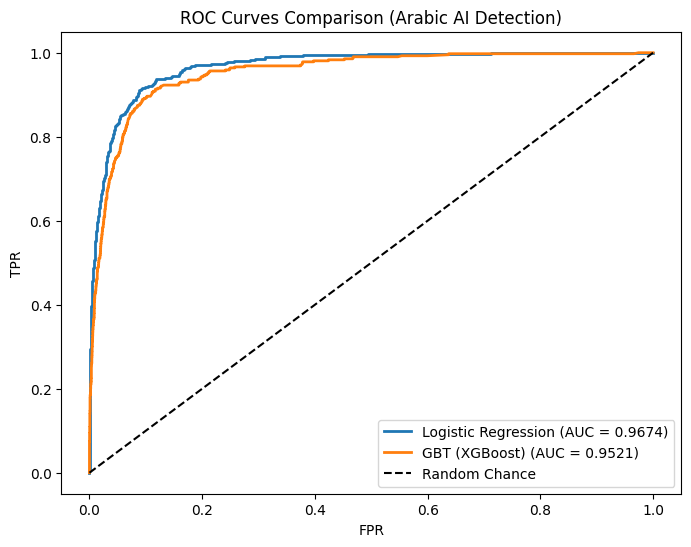

In [36]:
# حساب مقاييس الأداء لجميع الموديلات
models_to_eval = {
    "Logistic Regression": lr_model,
    "Linear SVM": svm_model,
    "GBT (XGBoost)": gbt_model
}

results = {}
for name, model in models_to_eval.items():
    results[name] = evaluate_model(model, test_df, name)

# confusion_matrix
plot_confusion_matrix(gbt_model, test_df, "GBT Classifier")

# ROC Curves

plt.figure(figsize=(8, 6))
for name in ["Logistic Regression", "GBT (XGBoost)"]:
    preds = models_to_eval[name].transform(test_df)
    scores = preds.select("label", "probability").rdd.map(lambda r: (float(r["label"]), float(r["probability"][1]))).toDF(["label", "score"]).toPandas()
    fpr, tpr, _ = roc_curve(scores["label"], scores["score"])
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {sk_auc(fpr, tpr):.4f})")

plt.plot([0, 1], [0, 1], "k--", label="Random Chance")
plt.title("ROC Curves Comparison (Arabic AI Detection)")
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.legend(); plt.show()

---

###  Task 4.4 — Scalability Benchmark: Throughput Analysis


Partitions   | Time (sec)
-------------------------
2            | 0.34      s
4            | 0.14      s
8            | 0.17      s
16           | 0.18      s


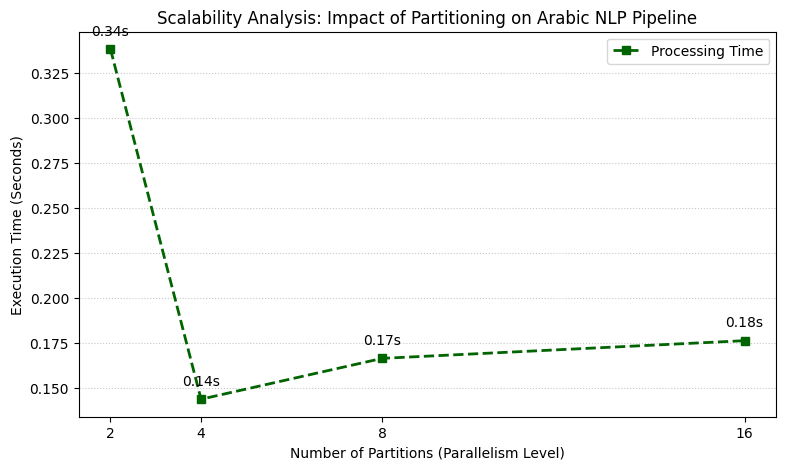

In [37]:
import time

# الإعدادات المقترحة بناءً على الـ 4 Processors التي خصصناها للماكينة
partition_configs = [2, 4, 8, 16]
scalability_results = {}

print(f"{'Partitions':<12} | {'Time (sec)':<10}")
print("-" * 25)

for n in partition_configs:
    # ضبط عدد التقسيمات في Spark
    spark.conf.set("spark.sql.shuffle.partitions", str(n))

    start_time = time.time()

    # استخدام repartition لقياس كفاءة التوزيع (Scalability)
    # نقوم بعمل count على البيانات التي تحتوي على F1 و F24
    temp_count = feat_df.repartition(n).count()

    duration = time.time() - start_time
    scalability_results[n] = duration

    print(f"{n:<12} | {duration:<10.2f}s")

# --- رسم النتائج بأسلوب متطور ---
plt.figure(figsize=(9, 5))
x_axis = list(scalability_results.keys())
y_axis = list(scalability_results.values())

plt.plot(x_axis, y_axis, marker='s', linestyle='--', color='darkgreen', linewidth=2, label='Processing Time')

# إضافة ملصقات نصية لكل نقطة لتسهيل القراءة في البحث
for i, txt in enumerate(y_axis):
    plt.annotate(f"{txt:.2f}s", (x_axis[i], y_axis[i]), textcoords="offset points", xytext=(0,10), ha='center')

plt.title("Scalability Analysis: Impact of Partitioning on Arabic NLP Pipeline")
plt.xlabel("Number of Partitions (Parallelism Level)")
plt.ylabel("Execution Time (Seconds)")
plt.xticks(partition_configs)
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.legend()
plt.show()



## Phase 5: Analysis, Interpretation & Final Reporting

> **Tasks:** 5.1 – 5.3



---

### Task 5.1 — Model Comparison Summary


In [38]:
import pandas as pd

# --- Combine all results into a clean summary table ---
summary_data = []

# تحديث القاموس ليشمل النتائج التي استخرجناها فعلياً
all_models = {
    "Logistic Regression": results["Logistic Regression"],
    "Linear SVM": results["Linear SVM"],
    "GBT (XGBoost)": results["GBT (XGBoost)"]
}

for model_name, metrics in all_models.items():
    summary_data.append({
        "Model": model_name,
        "Accuracy": round(metrics["Accuracy"], 4),
        "F1-Score": round(metrics["F1"], 4),
        "AUC-ROC": round(metrics["AUC"], 4) if metrics["AUC"] else "N/A",
        "Stylometric Features": "F1 & F24 Included", # تأكيد استخدام الميزات الجديدة
        "Platform": "CentOS Stream (50GB Disk)"
    })

# تحويل البيانات إلى DataFrame وترتيبها حسب الـ F1-Score
summary_df = pd.DataFrame(summary_data).sort_values("F1-Score", ascending=False)

print("=== Final Model Performance Comparison (Arabic AI Detection) ===")
print("-" * 80)
print(summary_df.to_string(index=False))
print("-" * 80)



=== Final Model Performance Comparison (Arabic AI Detection) ===
--------------------------------------------------------------------------------
              Model  Accuracy  F1-Score  AUC-ROC Stylometric Features                  Platform
         Linear SVM    0.9569    0.9547   0.9651    F1 & F24 Included CentOS Stream (50GB Disk)
Logistic Regression    0.9557    0.9521   0.9674    F1 & F24 Included CentOS Stream (50GB Disk)
      GBT (XGBoost)    0.9439    0.9336   0.9522    F1 & F24 Included CentOS Stream (50GB Disk)
--------------------------------------------------------------------------------


---

### Task 5.2 — Feature Importance Analysis


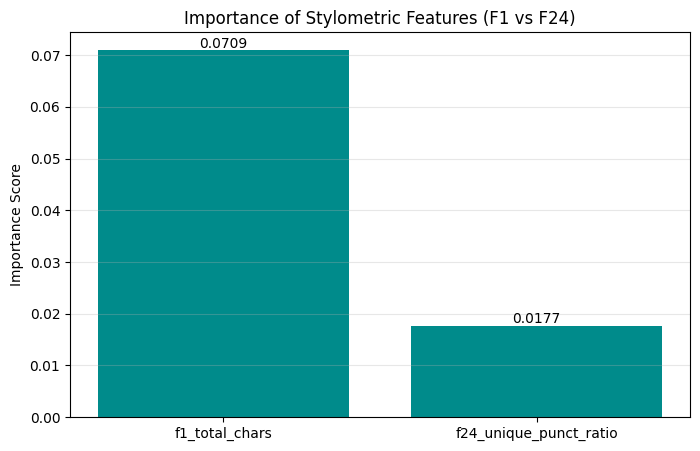

 Feature importance visualization (F1 & F24) saved to: /home/ahmed/arabic_ai_detection/reports/figures/feature_importance_F1_F24.png


In [39]:
import numpy as np
import matplotlib.pyplot as plt
import os

# --- 1. تحليل أهمية الميزات ( f1_total_chars و f24_unique_punct_ratio)
active_stylometric_cols = ["f1_total_chars", "f24_unique_punct_ratio"]

# استخراج أهمية الميزات من موديل
importances = gbt_model.featureImportances.toArray()
n_stylo = len(active_stylometric_cols)
stylo_imp = importances[:n_stylo]

plt.figure(figsize=(8, 5))
plt.bar(active_stylometric_cols, stylo_imp, color="darkcyan")
plt.ylabel("Importance Score")
plt.title("Importance of Stylometric Features (F1 vs F24)")
plt.grid(axis='y', alpha=0.3)

# إضافة توضيح فوق الأعمدة
for i, val in enumerate(stylo_imp):
    plt.text(i, val, f'{val:.4f}', ha='center', va='bottom')

# حفظ الرسم البياني في مجلد التقارير المحلي
fi_path = os.path.join(REPORTS_DIR, "feature_importance_F1_F24.png")
plt.savefig(fi_path, dpi=150)
plt.show()

print(f" Feature importance visualization (F1 & F24) saved to: {fi_path}")



In [40]:
# --- Generate requirements.txt for project
import subprocess, sys

req_path = os.path.join(PROJECT_ROOT, "requirements.txt")
# استخدام pip freeze لتوثيق المكتبات المحملة في CentOS
with open(req_path, "w") as f:
    subprocess.run([sys.executable, "-m", "pip", "freeze"], stdout=f)

print(f"Project requirements.txt generated at: {req_path}")

Project requirements.txt generated at: /home/ahmed/Downloads/requirements.txt


In [41]:
#  stop the SparkSession
spark.stop()
print("-" * 50)
print(" SparkSession terminated successfully.")
print(f"All models are saved in: {LOCAL_MODEL_PATH}")
print(f"Final reports available in: {REPORTS_DIR}")

--------------------------------------------------
 SparkSession terminated successfully.
All models are saved in: /home/ahmed/Downloads/trained_models
Final reports available in: /home/ahmed/arabic_ai_detection/reports/figures
